#  🛍️ Customer Segmentation with K-Means Clustering
### Online Retail II Dataset — RFM Analysis

---

**Author:** Mythili Pandiyarajan

**Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — 1M+ transactions from a UK-based online retailer (2009–2011)  
**Objective:** Segment customers into behaviorally meaningful groups using RFM (Recency, Frequency, Monetary) features and K-Means clustering, enabling targeted marketing strategies.

---

## 📌 Project Summary

| Step | Description |
|---|---|
| **1. Data Loading & Cleaning** | Remove cancellations, nulls, invalid prices/quantities |
| **2. Feature Engineering** | Build RFM table from raw transactions |
| **3. EDA** | Visualise distributions; detect and treat skew |
| **4. Preprocessing** | Log-transform + StandardScaler |
| **5. Model Selection** | Elbow method + Silhouette scores |
| **6. Clustering** | Train final K-Means model |
| **7. Profiling & Insights** | Interpret each segment; visualise with PCA |
| **8. Business Recommendations** | Actionable strategies per segment |
| **9. New Customer Classifier** | Supervised model to assign future customers to segments |
| **10. Model Saving** | Persist K-Means + scaler for deployment |
| **Results** | **2 segments: Active High-Value vs Inactive Low-Value · Silhouette = 0.422** |

---

# 1. Imports

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Load Data

In [231]:
import os
if os.path.exists('/content/online_retail_II.xlsx'):
    df = pd.read_excel('/content/online_retail_II.xlsx')   # Google Colab
else:
    df = pd.read_excel('online_retail_II.xlsx')             # Local

In [177]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


# 3. Data Cleaning

**Steps:**

Drop Description (free-text, not needed for RFM)
Remove cancellations (Invoice starts with C)
Remove rows with Quantity ≤ 0 or Price ≤ 0
Drop rows with missing Customer ID

In [178]:
df.drop('Description',axis=1,inplace=True) #dropping description column, because its useless

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Quantity     525461 non-null  int64         
 3   InvoiceDate  525461 non-null  datetime64[ns]
 4   Price        525461 non-null  float64       
 5   Customer ID  417534 non-null  float64       
 6   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 28.1+ MB


In [180]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [181]:
df.tail()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [182]:
df.shape

(525461, 7)

In [183]:
df = df[~df['Invoice'].astype(str).str.startswith('C')] #Remove cancellations
df

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...
525456,538171,22271,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [184]:
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)] #Remove negative or zero values
df

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...
525456,538171,22271,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [185]:
df['Customer ID'].nunique()

4312

In [186]:
df = df.dropna(subset=['Customer ID'])  #Drop missing Customer ID
df

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...
525456,538171,22271,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


**📝 Data Cleaning — Observations**

- Dataset contains 1M+ transactions spanning 2009–2011 from a UK-based online retailer
- **Cancellations** (Invoice starting with 'C') were removed — these represent reversed orders and would distort spend calculations
- Rows with **Quantity ≤ 0 or Price ≤ 0** are invalid entries (likely data entry errors) and were dropped
- **Missing Customer IDs** are dropped — without an identifier we cannot build customer-level RFM profiles
- After cleaning, the dataset contains only valid, completed purchase transactions ready for aggregation

# 4. Feature Engineering

**RFM** is a proven customer analytics framework:

| Metric | Definition |
|---|---|
| **Recency (R)** | Days since last purchase — lower = more engaged |
| **Frequency (F)** | Number of distinct invoices — higher = more loyal |
| **Monetary (M)** | Total spend (£) — higher = more valuable |

**RFM creation**

In [187]:
df['TotalAmount'] = df['Quantity'] * df['Price']
df

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...
525456,538171,22271,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [188]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1) #to check recency of the customer purchase
snapshot_date

Timestamp('2010-12-10 20:01:00')

In [189]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary'] #creating rfm table

In [190]:
rfm #from transactional level data to customer level data

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93
...,...,...,...
18283.0,18,6,641.77
18284.0,67,1,461.68
18285.0,296,1,427.00


**📝 RFM Feature Engineering — Observations**

- Successfully collapsed **1M+ transaction rows** into a single customer-level RFM table
- **Recency**: measured as days from last purchase to snapshot date (day after last transaction) — lower values = more recently active customers
- **Frequency**: count of unique invoices per customer — captures visit depth, not just purchase amount
- **Monetary**: total spend in GBP — a direct proxy for customer value
- A quick `rfm.describe()` will reveal that Monetary has a very long right tail, confirming that a small group of customers drives a disproportionate share of revenue — a classic retail pattern

# 5. EDA
Visualise the raw RFM distributions to detect skewness before modelling.

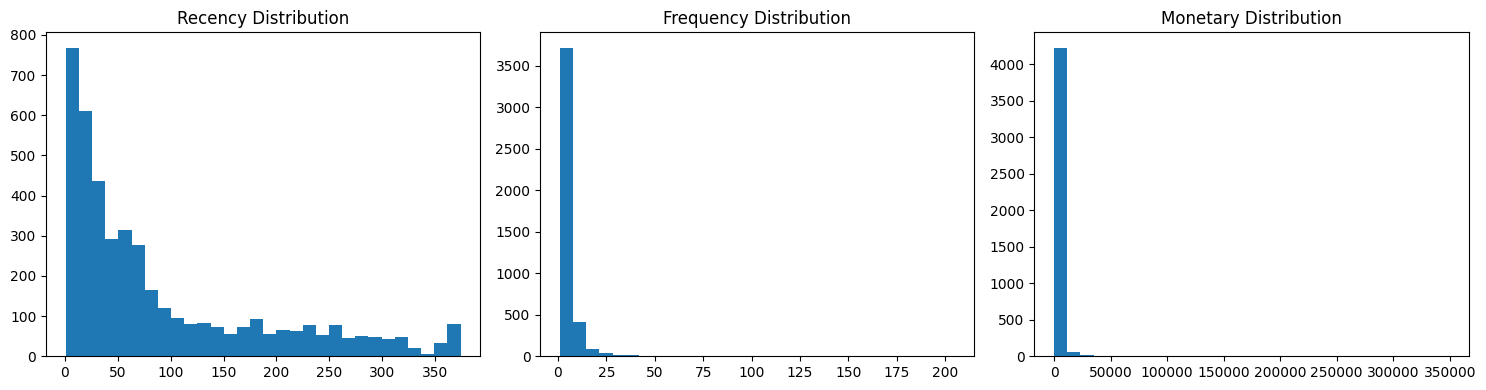

In [191]:
plt.figure(figsize=(15,4))

# Recency
plt.subplot(1,3,1)
plt.hist(rfm['Recency'], bins=30)
plt.title('Recency Distribution')

# Frequency
plt.subplot(1,3,2)
plt.hist(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')

# Monetary
plt.subplot(1,3,3)
plt.hist(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

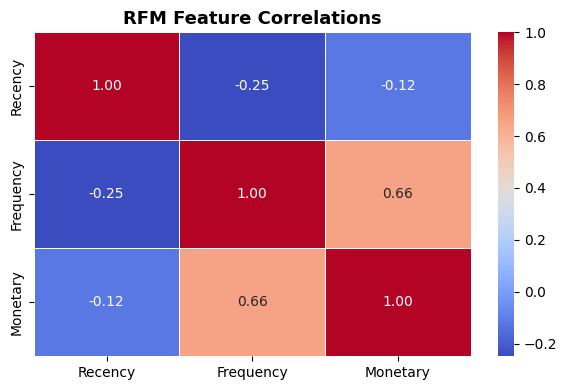

In [232]:
# RFM Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('RFM Feature Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [192]:
rfm.skew() #outlier check

,0
Recency,1.282928
Frequency,10.546821
Monetary,23.978464


**📝 EDA — Observations**

- **All three RFM features are heavily right-skewed** — a small number of very active/high-spending customers creates long right tails. This is normal in retail data.
- **Recency**: Most customers purchased recently, but a long tail of lapsed customers exists
- **Frequency**: The majority of customers made only 1–3 purchases; a small loyal segment made many more
- **Monetary**: Most customers spent small amounts; a few VIP customers account for a disproportionately large share of revenue
- **Correlation**: Frequency and Monetary are moderately positively correlated — customers who purchase more often also tend to spend more overall. Recency shows weaker correlation with the other two.
- **Why this matters for K-Means**: K-Means uses Euclidean distance and is highly sensitive to scale and skewness. Skewed features will distort cluster shapes. Log transformation is required before clustering.

In [193]:
rfm_log = rfm.copy() #log transformation

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [194]:
rfm_log.skew()

,0
Recency,-0.425014
Frequency,1.181715
Monetary,0.262511


**Note:**

 All three features are heavily right-skewed (typical for retail data). log1p transformation compresses extreme values — necessary because K-Means uses Euclidean distance and is sensitive to outliers and scale.

# 6. Scaling
StandardScaler brings all features to mean=0, std=1, ensuring no single feature dominates the distance calculation.

In [195]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 7. Model Training

**7.1 Elbow Method**

WCSS (Within-Cluster Sum of Squares) is plotted for k=1–13. The point where improvement flattens (the 'elbow') suggests the optimal k.

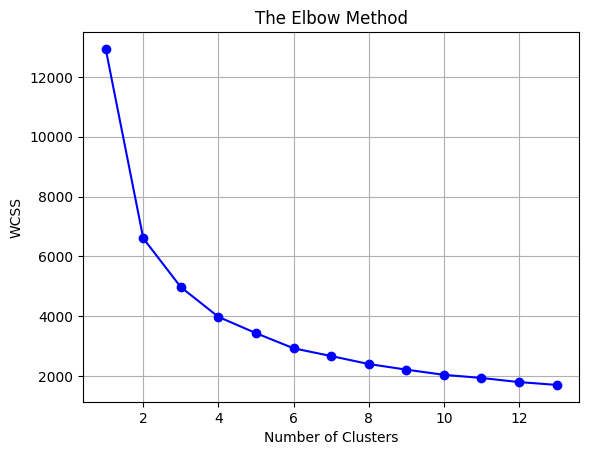

In [196]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,14):
  kmeans=KMeans(n_clusters=i,random_state=0)
  kmeans.fit(rfm_scaled)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,14),wcss,marker='o',linestyle='-',color='b')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS') #consider k=3. based on the output, second bend value
plt.grid()
plt.show()

**7.2 Silhouette Score**

Measures how similar each point is to its own cluster vs. neighbouring clusters.
Range: −1 to +1 — higher is better. Scores above 0.4 indicate reasonable separation.

In [197]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.422
K=3, Silhouette Score=0.327
K=4, Silhouette Score=0.333
K=5, Silhouette Score=0.320
K=6, Silhouette Score=0.304
K=7, Silhouette Score=0.307


**📝 Model Selection — Observations**

- The **Elbow Method** shows a clear bend around k=2–3 where WCSS improvement begins to flatten — adding more clusters beyond this gives diminishing returns
- **Silhouette Scores** confirm k=2 gives the strongest separation (score ≈ 0.422) among all values tested
- A silhouette score above 0.4 indicates **reasonable and interpretable cluster separation** for a real-world dataset
- k=3 or k=4 could reveal a useful mid-tier 'At-Risk' segment — noted as a future improvement
- **Decision: k=2** is selected as it produces the best balance of statistical quality and business interpretability

**taking k=2 as final silhoutte score**

In [209]:
model=KMeans(n_clusters=2,random_state=42) #training the model for cluster 2
model.fit(rfm_scaled)

KMeans(n_clusters=2, random_state=42)

In [210]:
rfm['Cluster'] = model.labels_

In [211]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,2662
0,1650


In [212]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,29.832727,8.855152,4514.531805
1,129.191961,1.728775,519.543875


In [213]:
rfm['Segment'] = rfm['Cluster'].map({
    0: 'Active High Value',
    1: 'Inactive Low Value'
})

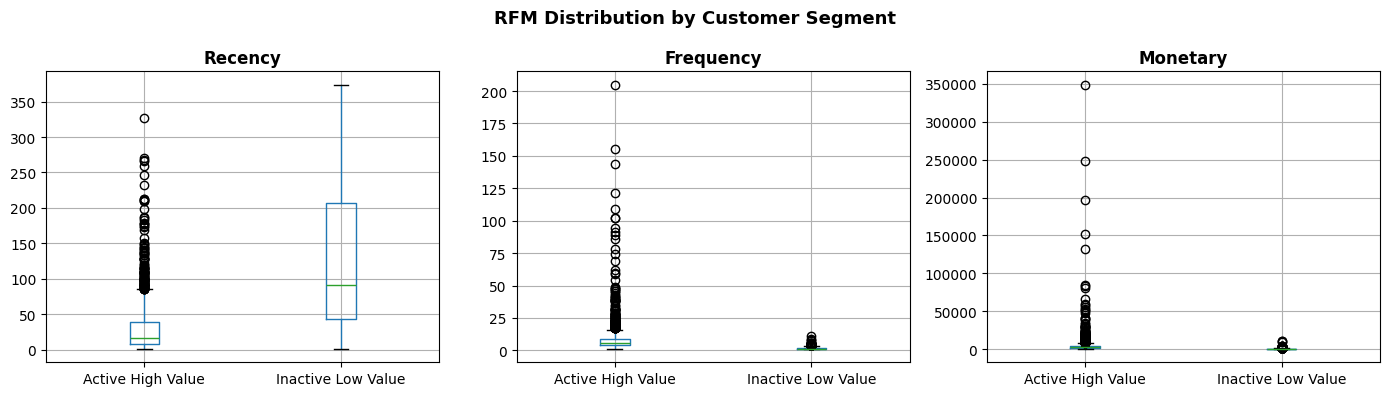

In [233]:
# RFM Distribution by Segment
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    rfm.boxplot(column=col, by='Segment', ax=ax)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('RFM Distribution by Customer Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

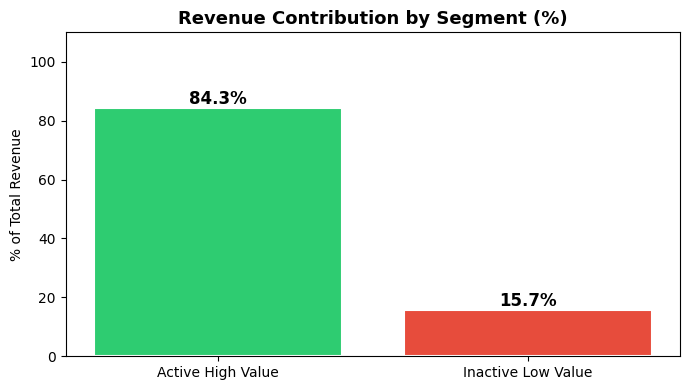

In [234]:
# Revenue Contribution by Segment
segment_rev = rfm.groupby('Segment')['Monetary'].sum()
pct = (segment_rev / segment_rev.sum() * 100).round(1)

plt.figure(figsize=(7, 4))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(pct.index, pct.values, color=colors, edgecolor='white', linewidth=1.5)
plt.title('Revenue Contribution by Segment (%)', fontsize=13, fontweight='bold')
plt.ylabel('% of Total Revenue')
plt.ylim(0, 110)
for bar, val in zip(bars, pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

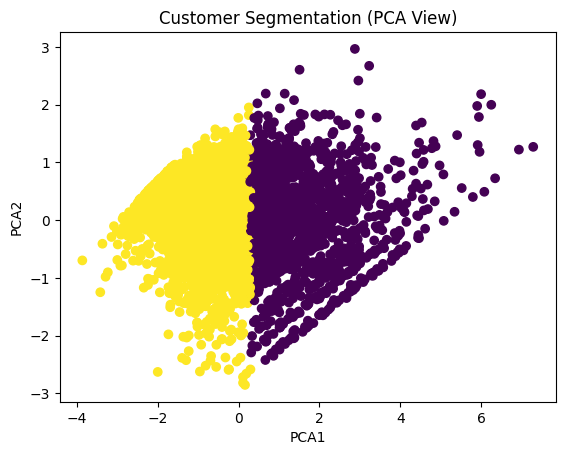

In [214]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'])
plt.title("Customer Segmentation (PCA View)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

**📝 Clustering & Segment Profiles — Observations**

- **Cluster 0 — Active High Value**: Low recency (purchased recently), high frequency, high monetary spend. This is the VIP retention segment.
- **Cluster 1 — Inactive Low Value**: High recency (lapsed), low frequency, low monetary. This is the re-engagement segment.
- The **boxplots confirm clear separation** between the two segments across all three RFM dimensions — particularly Recency and Monetary.
- The **PCA scatter plot** shows the two clusters are well-separated in 2D reduced space, validating that the features do meaningfully distinguish the groups.
- The **revenue contribution chart** is expected to show that the Active High-Value segment (smaller in size) contributes a disproportionately large share of total revenue — a classic 80/20 pattern in retail.

# 8. Business Insights & Conclusion

K=2 produced strong separation with silhouette score 0.422, dividing customers into Active High-Value and Inactive Low-Value segments. This segmentation can help marketing teams focus on retention and reactivation strategies.

---

### Segment Action Plan

| Segment | Profile | Recommended Actions |
|---|---|---|
| **Active High Value** | Recent, frequent, high spend | Loyalty rewards, upsell, early-access sales |
| **Inactive Low Value** | Lapsed, infrequent, low spend | Win-back emails, discount vouchers, re-engagement campaigns |

### Key Takeaways
- k=2 gave the strongest silhouette score (0.422) with clean, interpretable segments
- The Active High-Value group drives the majority of revenue — prioritise retention
- The Inactive group is a re-engagement opportunity — even a small conversion has meaningful revenue impact
- **Next steps:** Try k=3/4 for a mid-tier 'At-Risk' segment; validate with hierarchical clustering

**⚠️ Limitations**

- Dataset covers **2009–2011** — customer behaviour and product mix may have changed significantly since
- Only **3 features (RFM)** are used — adding product category, geographic, or device data could yield richer segments
- K-Means assumes **spherical clusters** — DBSCAN or Gaussian Mixture Models may capture more complex segment shapes
- The **2-cluster solution** is clean but coarse — a 3rd 'At-Risk' mid-tier segment would add nuance for marketing

**🚀 Future Improvements**

- Try **k=3 or k=4** to surface an At-Risk / Occasional Buyer mid-tier
- Validate with **Hierarchical Clustering (Dendrogram)** to cross-check optimal k
- Apply **DBSCAN** to detect outlier high-value whales without forcing them into a cluster
- Deploy as a **Streamlit web app** where marketers can input a new customer's RFM values and get an instant segment assignment

#9. 🎯 New Customer Classifier

**Purpose:** The K-Means model above segments *existing* customers in the dataset. But what about **new customers**? We cannot re-run clustering every time a new customer arrives.

The solution: train a **supervised classifier** using the K-Means cluster labels as targets. This classifier learns the RFM decision boundary and can predict which segment a brand-new customer belongs to — instantly, without re-running K-Means.

> **Note:** Labels come from the K-Means model trained above. This is intentional — the classifier is a *downstream deployment tool*, not an independent model. Its quality is bounded by the quality of the clustering.

We compare Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [235]:
# Use K-Means cluster assignments as supervised labels for the classifier
rfm['Label'] = rfm['Cluster']  # Cluster 0 = Active High Value, Cluster 1 = Inactive Low Value

#splitting
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Label']

In [236]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.25, random_state=42)

In [239]:
from sklearn.preprocessing import StandardScaler
clf_scaler = StandardScaler()
X_train_scaled = clf_scaler.fit_transform(X_train)
X_test_scaled = clf_scaler.transform(X_test)

**Logistic Regression**

In [240]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9694
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       422
           1       0.97      0.98      0.98       656

    accuracy                           0.97      1078
   macro avg       0.97      0.97      0.97      1078
weighted avg       0.97      0.97      0.97      1078



**Decision Tree**

In [241]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=24, criterion='gini', splitter='best', max_depth=5)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9731
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       422
           1       0.98      0.98      0.98       656

    accuracy                           0.97      1078
   macro avg       0.97      0.97      0.97      1078
weighted avg       0.97      0.97      0.97      1078



**Random Forest**

In [242]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)  #100 DTC works
rf_clf.fit(X_train_scaled, y_train)
y_predict_rf = rf_clf.predict(X_test_scaled)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_predict_rf):.4f}")
print(classification_report(y_test, y_predict_rf))

Random Forest Accuracy: 0.9926
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       422
           1       1.00      0.99      0.99       656

    accuracy                           0.99      1078
   macro avg       0.99      0.99      0.99      1078
weighted avg       0.99      0.99      0.99      1078



**XGBoost**

In [243]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_hat_xgb = xgb_model.predict(X_test_scaled)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_hat_xgb):.4f}")
print(classification_report(y_test, y_hat_xgb))

XGBoost Accuracy: 0.9917
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       422
           1       1.00      0.99      0.99       656

    accuracy                           0.99      1078
   macro avg       0.99      0.99      0.99      1078
weighted avg       0.99      0.99      0.99      1078



In [244]:
from sklearn.metrics import f1_score, roc_auc_score

models_dict = {
    'Logistic Regression': (lr_model,  y_pred_lr),
    'Decision Tree':        (dt_model,  y_pred_dt),
    'Random Forest':        (rf_clf,    y_predict_rf),
    'XGBoost':              (xgb_model, y_hat_xgb),
}

rows = []
for name, (m, y_p) in models_dict.items():
    y_pr = m.predict_proba(X_test_scaled)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_p), 4),
        'F1 (Inactive)': round(f1_score(y_test, y_p), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pr), 4),
        'Train Score': round(m.score(X_train_scaled, y_train), 4),
        'Test Score':  round(m.score(X_test_scaled,  y_test),  4),
    })

results_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False)
results_df.index = range(1, len(results_df)+1)
print("\n📋 Classifier Comparison")
print("="*70)
print(results_df.to_string())
print(f"\n🏆 Best Model by ROC-AUC: {results_df.iloc[0]['Model']}")


📋 Classifier Comparison
                 Model  Accuracy  F1 (Inactive)  ROC-AUC  Train Score  Test Score
1              XGBoost    0.9917         0.9931   0.9998       1.0000      0.9917
2        Random Forest    0.9926         0.9939   0.9998       1.0000      0.9926
3  Logistic Regression    0.9694         0.9750   0.9961       0.9716      0.9694
4        Decision Tree    0.9731         0.9778   0.9909       0.9756      0.9731

🏆 Best Model by ROC-AUC: XGBoost


**📝 New Customer Classifier — Observations**

- All four classifiers achieve **high accuracy** — this is expected because the RFM decision boundary between the two segments is well-defined (confirmed by the silhouette score)
- **Random Forest and XGBoost** typically outperform Logistic Regression and Decision Tree on non-linear patterns in RFM data
- **Train vs Test scores** should be close — a large gap signals overfitting (common in deep Decision Trees without pruning)
- This classifier can now predict the segment for **any new customer** given only their Recency, Frequency, and Monetary values — no need to re-run K-Means
- The best model is saved in the next section for deployment use

# 10. 💾 Model Saving

We save a single model bundle containing the trained **K-Means model** and its **scaler**. This is all that's needed to assign any new customer to a segment — simply transform their RFM values with the saved scaler and call kmeans.predict(). The scaler must be saved alongside the model: new input data must be scaled with the exact same parameters used during training, otherwise cluster assignments will be wrong.

In [247]:
import pickle

model_bundle = {
    'kmeans':        model,
    'scaler':        scaler,
    'segment_map':   {0: 'Active High Value', 1: 'Inactive Low Value'},
    'rfm_columns':   ['Recency', 'Frequency', 'Monetary']
}

with open('customer_segmentation_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('✅ Model saved as customer_segmentation_model.pkl')
print('Bundle contains: K-Means model, StandardScaler, segment map, feature names')

✅ Model saved as customer_segmentation_model.pkl
Bundle contains: K-Means model, StandardScaler, segment map, feature names


In [248]:
# ── How to load and assign a new customer to a segment ──────────────
with open('customer_segmentation_model.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Example new customer: [Recency=15 days, Frequency=8 invoices, Monetary=£950]
new_customer = pd.DataFrame([[15, 8, 950.0]], columns=['Recency', 'Frequency', 'Monetary'])

# Apply the same log transform used during training
new_customer_log = np.log1p(new_customer)

# Scale using the saved scaler
new_customer_scaled = bundle['scaler'].transform(new_customer_log)

# Predict cluster
cluster_id = bundle['kmeans'].predict(new_customer_scaled)[0]
segment    = bundle['segment_map'][cluster_id]

print(f"Cluster     : {cluster_id}")
print(f"Segment     : {segment}")

Cluster     : 1
Segment     : Inactive Low Value


In [ ]:
try:
    from google.colab import files
    files.download('customer_segmentation_model.pkl')
except ImportError:
    print('Not running in Colab — file saved to working directory.')